# DA6401 Assignment 1 - W&B Report Experiments
Covers all 10 questions for the W&B report.

In [ ]:
# Install dependencies if needed
# !pip install wandb scikit-learn numpy keras tensorflow

In [1]:
import sys
import os
sys.path.insert(0, os.path.join(os.path.dirname(os.getcwd()), 'src'))
# If running from notebooks folder, src is one level up

import numpy as np
import matplotlib.pyplot as plt
import wandb
from types import SimpleNamespace

from ann.neural_network import NeuralNetwork
from ann.activations import softmax
from ann.objective_functions import LOSS_FN, LOSS_GRAD
from utils.data_loader import load_data
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay, f1_score

In [2]:
#intialize the wand
WANDB_PROJECT = "da6401_assignment1"  
WANDB_ENTITY = None                  

def make_args(**kwargs):
    defaults = dict(
        dataset="mnist",
        epochs=10,
        batch_size=64,
        loss="cross_entropy",
        optimizer="rmsprop",
        learning_rate=1e-3,
        weight_decay=0.0,
        num_layers=3,
        hidden_size=[128, 128, 128],
        activation="relu",
        weight_init="xavier",
        wandb_project=WANDB_PROJECT,
        wandb_entity=WANDB_ENTITY,
    )
    defaults.update(kwargs)
    return SimpleNamespace(**defaults)

# Load data once
print("Loading MNIST...")
X_train, y_train, X_val, y_val, X_test, y_test = load_data("mnist")
print(f"Train: {X_train.shape}, Val: {X_val.shape}, Test: {X_test.shape}")

Loading MNIST...
Train: (54000, 784), Val: (6000, 784), Test: (10000, 784)


## Q1: Data Exploration and Class Distribution

In [ ]:
from keras.datasets import mnist as k_mnist
(raw_X, raw_y), _ = k_mnist.load_data()

run = wandb.init(project=WANDB_PROJECT, entity=WANDB_ENTITY, name="q1_data_exploration", job_type="eda")

class_names = [str(i) for i in range(10)]
table = wandb.Table(columns=["class", "image"])

# taking 5 images of each class
for cls in range(10):
    idxs = np.where(raw_y == cls)[0][:5]
    for idx in idxs:
        img = raw_X[idx]
        table.add_data(class_names[cls], wandb.Image(img))

run.log({"sample_images": table})

# Also log class distribution
unique, counts = np.unique(raw_y, return_counts=True)
dist_table = wandb.Table(data=[[str(c), int(n)] for c, n in zip(unique, counts)],
                          columns=["class", "count"])
run.log({"class_distribution": dist_table})

run.finish()
print("Q1 done")

Q1 done


## Q2: Hyperparameter Sweep (100+ runs)

In [ ]:
# sweep config for hyperparameter tuning with wandb with combination of these 

sweep_config = {
    "method": "bayes",
    "metric": {"name": "val_acc", "goal": "maximize"},
    "parameters": {
        "learning_rate": {"values": [1e-4, 5e-4, 1e-3, 5e-3]},
        "optimizer": {"values": ["sgd", "momentum", "nag", "rmsprop"]},
        "num_layers": {"values": [2, 3, 4]},
        "hidden_size_val": {"values": [64, 128]},
        "activation": {"values": ["relu", "tanh", "sigmoid"]},
        "weight_init": {"values": ["random", "xavier"]},
        "batch_size": {"values": [32, 64, 128]},
        "weight_decay": {"values": [0.0, 1e-4, 5e-4]},
        "loss": {"values": ["cross_entropy", "mse"]},
    },
}

def sweep_train():
    run = wandb.init()
    cfg = run.config

    args = make_args(
        dataset="mnist",
        epochs=5,
        batch_size=cfg.batch_size,
        loss=cfg.loss,
        optimizer=cfg.optimizer,
        learning_rate=cfg.learning_rate,
        weight_decay=cfg.weight_decay,
        num_layers=cfg.num_layers,
        hidden_size=[cfg.hidden_size_val] * cfg.num_layers,
        activation=cfg.activation,
        weight_init=cfg.weight_init,
    )

    model = NeuralNetwork(args)
    n = X_train.shape[0]

    for epoch in range(args.epochs):
        idx = np.random.permutation(n)
        Xtr, ytr = X_train[idx], y_train[idx]
        epoch_loss = 0.0
        for start in range(0, n, args.batch_size):
            Xb, yb = Xtr[start:start+args.batch_size], ytr[start:start+args.batch_size]
            logits = model.forward(Xb)
            epoch_loss += LOSS_FN[args.loss](logits, yb) * len(yb)
            model.backward(yb, logits)
            model.update_weights()
        epoch_loss /= n

        val_metrics = model.evaluate(X_val, y_val)
        run.log({
            "epoch": epoch + 1,
            "train_loss": epoch_loss,
            "val_acc": val_metrics["accuracy"],
            "val_loss": val_metrics["loss"],
        })

    run.finish()

sweep_id = wandb.sweep(sweep_config, project=WANDB_PROJECT, entity=WANDB_ENTITY)
print(f"Sweep ID: {sweep_id}")
print("Run: wandb.agent(sweep_id, sweep_train, count=100)")

Create sweep with ID: 2882zrwx
Sweep URL: https://wandb.ai/jaydeep316-i/da6401_assignment1/sweeps/2882zrwx
Sweep ID: 2882zrwx
Run: wandb.agent(sweep_id, sweep_train, count=100)


In [ ]:
# Execute the sweeps and logging in wandb
wandb.agent(sweep_id, sweep_train, count=100)

wandb: Agent Starting Run: nzbbn986 with config:
wandb: 	activation: relu
wandb: 	batch_size: 32
wandb: 	hidden_size_val: 128
wandb: 	learning_rate: 0.0001
wandb: 	loss: mse
wandb: 	num_layers: 2
wandb: 	optimizer: momentum
wandb: 	weight_decay: 0.0005
wandb: 	weight_init: xavier
wandb: [wandb.login()] Loaded credentials for https://api.wandb.ai from C:\Users\JAYDEEP\_netrc.


wandb: ERROR The nbformat package was not found. It is required to save notebook history.


epoch,▁▃▅▆█
train_loss,█▆▄▃▁
val_acc,▁▃▅▆█
val_loss,█▆▄▃▁
epoch,5
train_loss,0.08856
val_acc,0.21067
val_loss,0.08841


wandb: Agent Starting Run: xqvcgkiu with config:
wandb: 	activation: tanh
wandb: 	batch_size: 128
wandb: 	hidden_size_val: 64
wandb: 	learning_rate: 0.0001
wandb: 	loss: mse
wandb: 	num_layers: 4
wandb: 	optimizer: rmsprop
wandb: 	weight_decay: 0.0005
wandb: 	weight_init: xavier
wandb: [wandb.login()] Loaded credentials for https://api.wandb.ai from C:\Users\JAYDEEP\_netrc.


wandb: ERROR The nbformat package was not found. It is required to save notebook history.


...

wandb: ERROR The nbformat package was not found. It is required to save notebook history.


epoch,▁▃▅▆█
train_loss,█▂▂▁▁
val_acc,▆▁▄▂█
val_loss,▄█▄▆▁
epoch,5
train_loss,0.01078
val_acc,0.93567
val_loss,0.01002


wandb: Agent Starting Run: t64v3snx with config:
wandb: 	activation: relu
wandb: 	batch_size: 64
wandb: 	hidden_size_val: 128
wandb: 	learning_rate: 0.005
wandb: 	loss: mse
wandb: 	num_layers: 4
wandb: 	optimizer: rmsprop
wandb: 	weight_decay: 0
wandb: 	weight_init: xavier
wandb: [wandb.login()] Loaded credentials for https://api.wandb.ai from C:\Users\JAYDEEP\_netrc.


wandb: ERROR The nbformat package was not found. It is required to save notebook history.


epoch,▁▃▅▆█
train_loss,█▃▂▁▁
val_acc,▁▂▄▇█
val_loss,█▆▇▁▁
epoch,5
train_loss,0.00644
val_acc,0.96267
val_loss,0.00667


## Q3: Optimizer Showdown

In [ ]:
import wandb
import numpy as np
import uuid   


# to check which optimizer is best 
optimizers = ["sgd", "momentum", "nag", "rmsprop"]
lr_map = {"sgd": 1e-2, "momentum": 1e-2, "nag": 1e-2, "rmsprop": 1e-3}

for opt in optimizers:
    run = wandb.init(
        project=WANDB_PROJECT,
        entity=WANDB_ENTITY,
        name=f"q3_optimizer_{opt}",
        group="q3_optimizer_showdown",
        reinit=True,                  
        id=str(uuid.uuid4())          
    )

    args = make_args(
        optimizer=opt,
        learning_rate=lr_map[opt],
        num_layers=3,
        hidden_size=[128, 128, 128],
        activation="relu",
        epochs=10,
    )

    model = NeuralNetwork(args)
    n = X_train.shape[0]

    for epoch in range(args.epochs):
        idx = np.random.permutation(n)
        Xtr, ytr = X_train[idx], y_train[idx]
        epoch_loss = 0.0

        for start in range(0, n, args.batch_size):
            Xb = Xtr[start:start+args.batch_size]
            yb = ytr[start:start+args.batch_size]

            logits = model.forward(Xb)
            epoch_loss += LOSS_FN[args.loss](logits, yb) * len(yb)

            model.backward(yb, logits)
            model.update_weights()

        epoch_loss /= n

        val_m = model.evaluate(X_val, y_val)
        # logging details of each epoch
        run.log({
            "epoch": epoch + 1,
            "train_loss": epoch_loss,
            "val_acc": val_m["accuracy"],
            "optimizer": opt
        })

    run.finish()
    print(f"Done: {opt}, Run ID: {run.id}")

wandb: [wandb.login()] Loaded credentials for https://api.wandb.ai from C:\Users\JAYDEEP\_netrc.
wandb: Currently logged in as: jaydeep316 (jaydeep316-i) to https://api.wandb.ai. Use `wandb login --relogin` to force relogin
wandb: WARNING Using a boolean value for 'reinit' is deprecated. Use 'return_previous' or 'finish_previous' instead.


wandb: ERROR The nbformat package was not found. It is required to save notebook history.


epoch,▁▂▃▃▄▅▆▆▇█
train_loss,█▃▂▂▂▁▁▁▁▁
val_acc,▁▃▄▅▆▇▇▇██
epoch,10
optimizer,sgd
train_loss,0.1552
val_acc,0.9515


Done: sgd, Run ID: 7361273d-3cab-4a92-9c66-1cf9a98b62f0


wandb: ERROR The nbformat package was not found. It is required to save notebook history.


...

epoch,▁▂▃▃▄▅▆▆▇█
train_loss,█▄▃▂▂▂▁▁▁▁
val_acc,▁▃▆▇▆▇▇██▇
epoch,10
optimizer,nag
train_loss,0.02356
val_acc,0.97217


Done: nag, Run ID: 2ce837fc-86a6-4048-bfcb-0835bd91d67f


wandb: ERROR The nbformat package was not found. It is required to save notebook history.


epoch,▁▂▃▃▄▅▆▆▇█
train_loss,█▄▃▂▂▂▁▁▁▁
val_acc,▁▅▄▆▇▇▇█▇█
epoch,10
optimizer,rmsprop
train_loss,0.02284
val_acc,0.97583


Done: rmsprop, Run ID: 52ba8200-49b0-4e7e-94ee-1ac28b2a0eeb


### getting best model using sweeps

In [ ]:
import wandb
import json

WANDB_PROJECT = "da6401_assignment1"
WANDB_ENTITY = None  

api = wandb.Api()

entity = WANDB_ENTITY or api.default_entity
runs = api.runs(f"{entity}/{WANDB_PROJECT}")

best_run = None
best_val_acc = -1

for run in runs:
    if run.state != "finished":
        continue

    summary = run.summary
    val_acc = summary.get("val_acc", -1)

    if val_acc > best_val_acc:
        best_val_acc = val_acc
        best_run = run
# if its the best run take the config and print the same
if best_run is None:
    print("No finished runs found.")
else:
    print(f"Best run : {best_run.name}")
    print(f"Run ID   : {best_run.id}")
    print(f"Val Acc  : {best_val_acc:.4f}")
    print("\nBest config:")

    cfg = dict(best_run.config)

    # remove wandb internal keys
    clean_cfg = {k: v for k, v in cfg.items() if not k.startswith("_")}

    for k, v in clean_cfg.items():
        print(f"  {k}: {v}")

    # save to json
    # with open("best_config.json", "w") as f:
    #     json.dump(clean_cfg, f, indent=4)

    # print("\nSaved best config to best_config.json")

Best run : deep-sweep-87
Run ID   : rklxs88c
Val Acc  : 0.9742

Best config:
  loss: cross_entropy
  optimizer: rmsprop
  activation: relu
  batch_size: 128
  num_layers: 4
  weight_init: xavier
  weight_decay: 0
  learning_rate: 0.001
  hidden_size_val: 128


## Q4: Vanishing Gradient Analysis

In [ ]:
import uuid

# check vanishing grad problemss with sigmoid and relu
for act in ["sigmoid", "relu"]:
    for nhl in [3, 5]:
        run = wandb.init(
            project=WANDB_PROJECT,
            entity=WANDB_ENTITY,
            name=f"q4_{act}_{nhl}layers",
            group="q4_vanishing_gradient",
            reinit=True,                 
            id=str(uuid.uuid4())         
        )

        args = make_args(
            optimizer="rmsprop",
            learning_rate=1e-3,
            activation=act,
            num_layers=nhl,
            hidden_size=[64] * nhl,
            epochs=5,
        )

        model = NeuralNetwork(args)
        n = X_train.shape[0]
        step = 0

        for epoch in range(args.epochs):
            idx = np.random.permutation(n)
            Xtr, ytr = X_train[idx], y_train[idx]

            for start in range(0, n, args.batch_size):
                Xb = Xtr[start:start+args.batch_size]
                yb = ytr[start:start+args.batch_size]

                logits = model.forward(Xb)
                model.backward(yb, logits)
                model.update_weights()

                # log gradient norm of first hidden layer
                if step % 50 == 0:
                    grad_norm = np.linalg.norm(model.layers[0].grad_W)

                    run.log({
                        "step": step,
                        "first_layer_grad_norm": grad_norm,
                        "activation": act,
                        "num_layers": nhl
                    })

                step += 1

        run.finish()
        print(f"Done: {act} {nhl}L, Run ID: {run.id}")

wandb: ERROR The nbformat package was not found. It is required to save notebook history.


first_layer_grad_norm,▁▁▂▁▂▂▃▃▄▄▃▅▄▄▅▅▂▅▄▆▅▄▆▄▄▅▂▄▆▅▄█▇▆▆▅▇▄▄█
num_layers,▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁
step,▁▁▁▂▂▂▂▂▂▃▃▃▃▃▃▄▄▄▅▅▅▅▅▅▆▆▆▆▆▆▇▇▇▇▇▇████
activation,sigmoid
first_layer_grad_norm,0.22991
num_layers,3
step,4200


Done: sigmoid 3L, Run ID: 7da96a53-3f42-491d-bf5c-f76eda4c55ed


wandb: ERROR The nbformat package was not found. It is required to save notebook history.


first_layer_grad_norm,▁▁▂▂▂▂▄▃▄▃▅▅▅▅▅▅▆▅▆▄▄▆▅▅▅▇▆▇▇▆▅█▆▄█▇█▆▆▇
num_layers,▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁
step,▁▁▂▂▂▂▃▃▃▃▃▄▄▄▄▄▄▄▅▅▅▅▅▆▆▆▆▆▆▆▇▇▇▇▇▇████
activation,sigmoid
first_layer_grad_norm,0.55712
num_layers,5
step,4200


...

first_layer_grad_norm,▆▅▅▆▅▅▄▅▅▅▃▄▄▆▄▅▄█▄▅▅▃▄▄▅▆▆▄▃▃▁▅▂▅▄▄▅▄▃▃
num_layers,▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁
step,▁▁▁▁▂▂▂▂▂▃▃▃▃▃▃▃▄▄▄▄▄▄▅▅▅▅▆▆▆▆▆▇▇▇▇▇▇▇██
activation,relu
first_layer_grad_norm,0.5636
num_layers,3
step,4200


Done: relu 3L, Run ID: 30e6ec65-88f1-4239-9e13-81a3a6f6cc22


wandb: ERROR The nbformat package was not found. It is required to save notebook history.


first_layer_grad_norm,▂█▅▇▃▄▇▇▄▄▄▅▅▇▆▆▃▅▆▂▄▅▂▂▄▂▃▅▁▂▆▅▄▃▃▃▄▃▃▅
num_layers,▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁
step,▁▁▁▂▂▂▃▃▃▃▃▃▃▄▄▄▄▄▅▅▅▅▅▅▅▆▆▆▆▆▆▆▇▇▇▇▇███
activation,relu
first_layer_grad_norm,1.2255
num_layers,5
step,4200


Done: relu 5L, Run ID: 87fd7f4e-b2dc-40bc-9d78-edfd757c20c0


## Q5: Dead Neuron Investigation

In [ ]:
import uuid
# checking dead neuron problem with relu and compare it to tanh

for act, lr in [("relu", 0.1), ("tanh", 0.1)]:
    run = wandb.init(
        project=WANDB_PROJECT,
        entity=WANDB_ENTITY,
        name=f"q5_{act}_lr0.1",
        group="q5_dead_neurons",
        reinit=True,                 
        id=str(uuid.uuid4())         
    )

    args = make_args(
        optimizer="sgd",
        learning_rate=lr,
        activation=act,
        num_layers=3,
        hidden_size=[128, 128, 128],
        epochs=10,
    )

    model = NeuralNetwork(args)
    n = X_train.shape[0]

    for epoch in range(args.epochs):
        idx = np.random.permutation(n)
        Xtr, ytr = X_train[idx], y_train[idx]
        epoch_loss = 0.0

        for start in range(0, n, args.batch_size):
            Xb = Xtr[start:start+args.batch_size]
            yb = ytr[start:start+args.batch_size]

            logits = model.forward(Xb)
            epoch_loss += LOSS_FN[args.loss](logits, yb) * len(yb)

            model.backward(yb, logits)
            model.update_weights()

        epoch_loss /= n

        # dead neuron calculate
        _ = model.forward(X_val[:500])
        act_h1 = model.layers[0]._z

        if act == "relu":
            dead_frac = np.mean(np.all(act_h1 <= 0, axis=0))
        else:
            dead_frac = 0.0

        val_m = model.evaluate(X_val, y_val)

        run.log({
            "epoch": epoch + 1,
            "train_loss": epoch_loss,
            "val_acc": val_m["accuracy"],
            "dead_neuron_fraction": dead_frac,
            "activation": act
        })

    run.finish()
    print(f"Done: {act}, Run ID: {run.id}")

wandb: ERROR The nbformat package was not found. It is required to save notebook history.


dead_neuron_fraction,▁█████████
epoch,▁▂▃▃▄▅▆▆▇█
train_loss,█▃▃▂▂▂▁▁▁▁
val_acc,▁▄▅▆▇▇▆▇██
activation,relu
dead_neuron_fraction,0.00781
epoch,10
train_loss,0.02396
val_acc,0.974


Done: relu, Run ID: e9d3d055-6b22-4730-b88b-c934284b4004


wandb: ERROR The nbformat package was not found. It is required to save notebook history.


dead_neuron_fraction,▁▁▁▁▁▁▁▁▁▁
epoch,▁▂▃▃▄▅▆▆▇█
train_loss,█▄▃▂▂▂▂▁▁▁
val_acc,▁▄▅▆▆▇▇▇██
activation,tanh
dead_neuron_fraction,0
epoch,10
train_loss,0.03427
val_acc,0.97567


Done: tanh, Run ID: f573f671-4ad9-4fe3-9cf8-adfa90eb224e


## Q6: Loss Function Comparison

In [ ]:
# comparing mse with cross entropy generally cross entropy is good for classification task

for loss_fn in ["cross_entropy", "mse"]:
    run = wandb.init(project=WANDB_PROJECT, entity=WANDB_ENTITY,
                     name=f"q6_{loss_fn}", group="q6_loss_comparison", reinit=True, id=str(uuid.uuid4()))
    
    args = make_args(
        optimizer="rmsprop",
        learning_rate=1e-3,
        loss=loss_fn,
        num_layers=3,
        hidden_size=[128, 128, 128],
        activation="relu",
        epochs=15,
    )
    model = NeuralNetwork(args)
    n = X_train.shape[0]

    for epoch in range(args.epochs):
        idx = np.random.permutation(n)
        Xtr, ytr = X_train[idx], y_train[idx]
        epoch_loss = 0.0
        for start in range(0, n, args.batch_size):
            Xb, yb = Xtr[start:start+args.batch_size], ytr[start:start+args.batch_size]
            logits = model.forward(Xb)
            epoch_loss += LOSS_FN[args.loss](logits, yb) * len(yb)
            model.backward(yb, logits)
            model.update_weights()
        epoch_loss /= n

        val_m = model.evaluate(X_val, y_val)
        train_m = model.evaluate(X_train[:5000], y_train[:5000])
        # logging details of every epochs
        run.log({
            "epoch": epoch+1,
            "train_loss": epoch_loss,
            "val_acc": val_m["accuracy"],
            "train_acc": train_m["accuracy"],
        })

    run.finish()
    print(f"Done: {loss_fn}")

wandb: ERROR The nbformat package was not found. It is required to save notebook history.


epoch,▁▁▂▃▃▃▄▅▅▅▆▇▇▇█
train_acc,▁▄▄▆▆▅▆▇▆██████
train_loss,█▄▃▂▂▂▂▁▁▁▁▁▁▁▁
val_acc,▁▄▄▄▆▅▆▇▅▇▇██▇▇
epoch,15
train_acc,0.996
train_loss,0.0149
val_acc,0.977


Done: cross_entropy


wandb: ERROR The nbformat package was not found. It is required to save notebook history.


epoch,▁▁▂▃▃▃▄▅▅▅▆▇▇▇█
train_acc,▁▃▁▅▆▅▆▇▇▆▇▇▇██
train_loss,█▄▃▂▂▂▂▂▁▁▁▁▁▁▁
val_acc,▁▅▁▄▆▅▇██▆▇▇▇██
epoch,15
train_acc,0.9932
train_loss,0.00129
val_acc,0.97733


Done: mse


## Q7: Global Performance Analysis (overlay all runs)
This will be done via W&B UI parallel coordinates / overlay plot. Here we log all runs to the same group tp check global performance

In [ ]:
# Run a quick set of representative configs and log train vs test acc
configs_q7 = [
    dict(optimizer="sgd",      learning_rate=1e-2, num_layers=2, hidden_size=[64,64],      activation="relu"),
    dict(optimizer="rmsprop",  learning_rate=1e-3, num_layers=3, hidden_size=[128,128,128], activation="relu"),
    dict(optimizer="momentum", learning_rate=1e-2, num_layers=3, hidden_size=[128,128,128], activation="tanh"),
    dict(optimizer="nag",      learning_rate=1e-2, num_layers=4, hidden_size=[64]*4,        activation="relu"),
    dict(optimizer="rmsprop",  learning_rate=5e-3, num_layers=3, hidden_size=[128,128,128], activation="sigmoid"),
]

for i, cfg in enumerate(configs_q7):
    run = wandb.init(project=WANDB_PROJECT, entity=WANDB_ENTITY,
                     name=f"q7_run_{i}", group="q7_global_analysis", reinit=True, id=str(uuid.uuid4()))
    args = make_args(epochs=10, **cfg)
    model = NeuralNetwork(args)
    n = X_train.shape[0]

    for epoch in range(args.epochs):
        idx = np.random.permutation(n)
        Xtr, ytr = X_train[idx], y_train[idx]
        epoch_loss = 0.0
        for start in range(0, n, args.batch_size):
            Xb, yb = Xtr[start:start+args.batch_size], ytr[start:start+args.batch_size]
            logits = model.forward(Xb)
            epoch_loss += LOSS_FN[args.loss](logits, yb) * len(yb)
            model.backward(yb, logits)
            model.update_weights()
        epoch_loss /= n

        train_m = model.evaluate(X_train[:5000], y_train[:5000])
        test_m = model.evaluate(X_test, y_test)
        # logging details of each epoch and comparing train and test acc
        run.log({"epoch": epoch+1, "train_acc": train_m["accuracy"], "test_acc": test_m["accuracy"]})

    run.finish()
    print(f"Q7 run {i} done")

wandb: ERROR The nbformat package was not found. It is required to save notebook history.


epoch,▁▂▃▃▄▅▆▆▇█
test_acc,▁▄▅▆▆▇▇███
train_acc,▁▄▄▅▆▇▇▇██
epoch,10
test_acc,0.9428
train_acc,0.9438


Q7 run 0 done


wandb: ERROR The nbformat package was not found. It is required to save notebook history.


epoch,▁▂▃▃▄▅▆▆▇█
test_acc,▁▄▅▇▇▆█▇▅█
train_acc,▁▃▅▆▆▆▇█▇█
epoch,10
test_acc,0.9786
train_acc,0.9954


...

epoch,▁▂▃▃▄▅▆▆▇█
test_acc,▁▄▄▆▆▆▇▇█▆
train_acc,▁▃▅▆▆▇▇▇█▇
epoch,10
test_acc,0.9683
train_acc,0.986


Q7 run 3 done


wandb: ERROR The nbformat package was not found. It is required to save notebook history.


epoch,▁▂▃▃▄▅▆▆▇█
test_acc,▁▄▇▇██▆▇▇█
train_acc,▁▃▆▆▇▇▇███
epoch,10
test_acc,0.9759
train_acc,0.992


Q7 run 4 done


## Q8: Error Analysis - Confusion Matrix

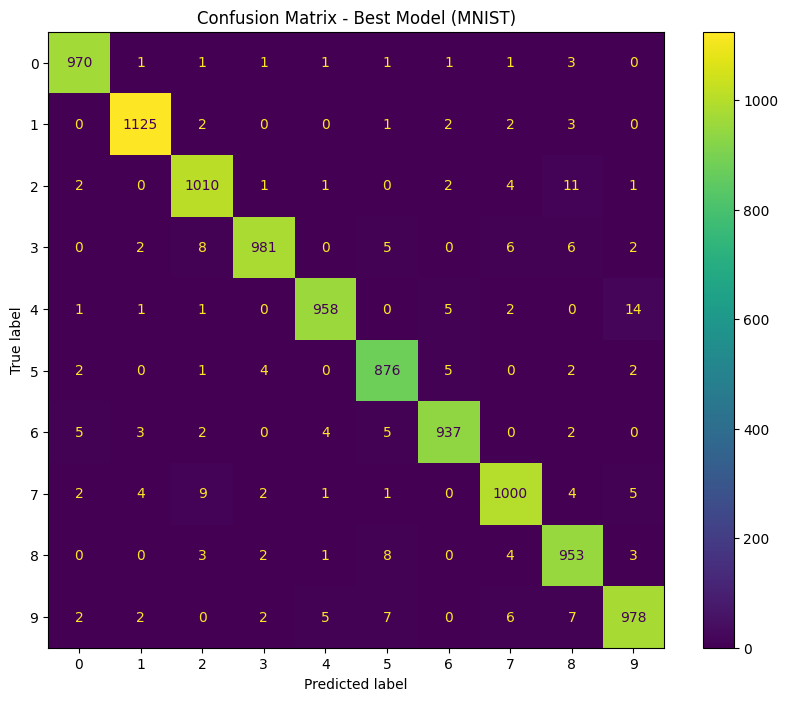

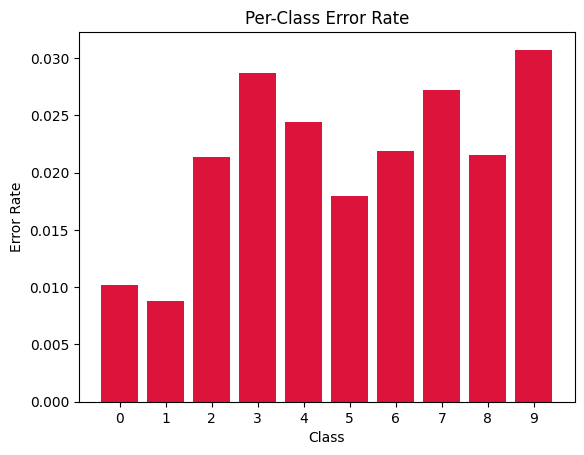

wandb: ERROR The nbformat package was not found. It is required to save notebook history.


epoch,▁▁▂▃▃▃▄▅▅▅▆▇▇▇█
val_acc,▁▅▂▇▇█▆▆▇▇██▆▆▆
val_f1,▁▅▂▇▇█▆▆▇▇██▆▆▆
epoch,15
val_acc,0.97283
val_f1,0.97266


Best val F1: 0.9773


In [ ]:
# Train best model and plot confusion matrix
run = wandb.init(project=WANDB_PROJECT, entity=WANDB_ENTITY, name="q8_error_analysis", group="q8_error_analysis", reinit=True, id=str(uuid.uuid4()))

# best config we got from sweeps
args = make_args(
    optimizer="rmsprop",
    learning_rate=1e-3,
    num_layers=4,
    hidden_size=[128, 128, 128],
    activation="relu",
    weight_init="xavier",
    epochs=15,
)
model = NeuralNetwork(args)
n = X_train.shape[0]
best_f1, best_w = -1, None

for epoch in range(args.epochs):
    idx = np.random.permutation(n)
    Xtr, ytr = X_train[idx], y_train[idx]
    for start in range(0, n, args.batch_size):
        Xb, yb = Xtr[start:start+args.batch_size], ytr[start:start+args.batch_size]
        logits = model.forward(Xb)
        model.backward(yb, logits)
        model.update_weights()

    val_m = model.evaluate(X_val, y_val)
    run.log({"epoch": epoch+1, "val_acc": val_m["accuracy"], "val_f1": val_m["f1"]})
    if val_m["f1"] > best_f1:
        best_f1 = val_m["f1"]
        best_w = model.get_weights()

model.set_weights(best_w)
logits = model.forward(X_test)
preds = np.argmax(logits, axis=1)

# plotting the confusion matrix
cm = confusion_matrix(y_test, preds)
fig, ax = plt.subplots(figsize=(10, 8))
disp = ConfusionMatrixDisplay(cm, display_labels=list(range(10)))
disp.plot(ax=ax, colorbar=True)
ax.set_title("Confusion Matrix - Best Model (MNIST)")
run.log({"confusion_matrix": wandb.Image(fig)})

# plotting the per-class error rate bar chart
error_rates = 1 - cm.diagonal() / cm.sum(axis=1)
fig2, ax2 = plt.subplots()
ax2.bar(range(10), error_rates, color="crimson")
ax2.set_xlabel("Class")
ax2.set_ylabel("Error Rate")
ax2.set_title("Per-Class Error Rate")
ax2.set_xticks(range(10))
run.log({"per_class_error_rate": wandb.Image(fig2)})

plt.show()
run.finish()
print(f"Best val F1: {best_f1:.4f}")

## Q9: Weight Initialization & Symmetry Breaking

In [9]:
from ann.neural_layer import Layer
from ann.activations import ACT_FN, ACT_GRAD

# Zeros init custom layer for demonstration
class ZeroLayer(Layer):
    def _init_weights(self, in_dim, out_dim, method):
        self.W = np.zeros((in_dim, out_dim))
        self.b = np.zeros((1, out_dim))

def build_zero_model(args):
    # Monkey-patch to use zero init for first layer
    model = NeuralNetwork(args)
    # Replace all layers with zero-init
    import importlib
    hidden_sizes = args.hidden_size
    dims = [784] + hidden_sizes + [10]
    new_layers = []
    for i in range(len(dims)-1):
        act = args.activation if i < len(dims)-2 else None
        l = Layer.__new__(Layer)
        l.activation = act
        l.W = np.zeros((dims[i], dims[i+1]))
        l.b = np.zeros((1, dims[i+1]))
        l.grad_W = None
        l.grad_b = None
        l._input = None
        l._z = None
        new_layers.append(l)
    model.layers = new_layers
    from ann.optimizers import OPTIMIZERS
    model.optimizer = OPTIMIZERS[args.optimizer](lr=args.learning_rate, weight_decay=args.weight_decay)
    model.optimizer.init_state(model.layers)
    return model

n_neurons_to_track = 5

for init_type in ["zeros", "xavier"]:
    run = wandb.init(project=WANDB_PROJECT, entity=WANDB_ENTITY,
                     name=f"q9_{init_type}_init", group="q9_weight_init", reinit=True, id=str(uuid.uuid4()))
    args = make_args(
        optimizer="sgd",
        learning_rate=1e-2,
        num_layers=3,
        hidden_size=[64, 64, 64],
        activation="relu",
        weight_init="xavier",
        epochs=3,
        batch_size=64,
    )

    if init_type == "zeros":
        model = build_zero_model(args)
    else:
        model = NeuralNetwork(args)

    step = 0
    n = X_train.shape[0]
    for epoch in range(args.epochs):
        idx = np.random.permutation(n)
        Xtr, ytr = X_train[idx], y_train[idx]
        for start in range(0, n, args.batch_size):
            Xb, yb = Xtr[start:start+args.batch_size], ytr[start:start+args.batch_size]
            logits = model.forward(Xb)
            model.backward(yb, logits)
            model.update_weights()

            if step < 50:
                gW = model.layers[0].grad_W  # (784, 64)
                log_dict = {"step": step}
                for nid in range(n_neurons_to_track):
                    log_dict[f"neuron_{nid}_grad_norm"] = np.linalg.norm(gW[:, nid])
                run.log(log_dict)
            step += 1

    run.finish()
    print(f"Done: {init_type}")

wandb: ERROR The nbformat package was not found. It is required to save notebook history.


neuron_0_grad_norm,▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁
neuron_1_grad_norm,▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁
neuron_2_grad_norm,▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁
neuron_3_grad_norm,▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁
neuron_4_grad_norm,▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁
step,▁▁▁▁▂▂▂▂▃▃▃▃▃▃▄▄▄▄▄▄▅▅▅▅▅▆▆▆▆▆▆▇▇▇▇▇▇███
neuron_0_grad_norm,0
neuron_1_grad_norm,0
neuron_2_grad_norm,0
neuron_3_grad_norm,0
neuron_4_grad_norm,0


Done: zeros


wandb: ERROR The nbformat package was not found. It is required to save notebook history.


neuron_0_grad_norm,▂▂▂▂▂▃▁▃▁▃▁▂▂▁▁▃▂▂█▃▂▂▂▂▃▄▇▃▃▆▄▅▁▂▂▃▄▄▆▂
neuron_1_grad_norm,▂▂▂▁▆▃▃▁▄▂▃▂▂▄▃▆▂▃▃▃▄▃▂▃▂▃▂▃▃▁▅▂▃▃▄▂▂█▄▃
neuron_2_grad_norm,▃▇▃▃▃▄▃▆▆▅▃▁▁█▅▅▄▃▁▃▃▃▄▅▄▃▃▅▆▄▃▅▆▆▂▃▄▅▃▇
neuron_3_grad_norm,▅▃▅▃▃█▁▄▂▃▂▁▃▅█▂▃▃▄▁▄▂▃▂▂▂▄▃▄▃▄▂▂▂▄▂▂▃▃▂
neuron_4_grad_norm,▅▇▆▇▆▆█▇▂▆▄▇▅▄▂▂▄▅▁▆▃▃▄▄▂▃▁▁▅▃▃▁▄▃▄▂▆▁▃▂
step,▁▁▁▁▂▂▂▂▂▃▃▃▃▃▃▄▄▄▄▄▅▅▅▅▅▅▆▆▆▆▆▆▇▇▇▇▇███
neuron_0_grad_norm,0.06093
neuron_1_grad_norm,0.08647
neuron_2_grad_norm,0.12557
neuron_3_grad_norm,0.08932
neuron_4_grad_norm,0.05846


Done: xavier


## Q10: Fashion-MNIST Transfer Challenge

In [ ]:
print("Loading Fashion-MNIST...")
Xf_train, yf_train, Xf_val, yf_val, Xf_test, yf_test = load_data("fashion_mnist")

# 3 configurations based on MNIST learning ( best config for mnist)
config_1 = dict(
    name="config1_rmsprop_reg",
    optimizer="rmsprop",          # same
    learning_rate=5e-4,           # changed
    weight_decay=5e-4,            # changed
    num_layers=4,
    hidden_size=[128]*4,
    activation="relu"
)

config_2 = dict(
    name="config2_nag_reg",
    optimizer="nag",              # changed
    learning_rate=5e-4,           # changed
    weight_decay=5e-4,            # changed
    num_layers=4,
    hidden_size=[128]*4,
    activation="relu"
)

config_3 = dict(
    name="config3_tanh_reg",
    optimizer="rmsprop",
    learning_rate=5e-4,           # changed
    weight_decay=5e-4,            # changed
    activation="tanh",            # changed
    num_layers=4,
    hidden_size=[128]*4
)

fmnist_configs = [
    config_1,
    config_2,
    config_3,
]

# checking the diffrent configs
for cfg in fmnist_configs:
    name = cfg.pop("name")
    run = wandb.init(project=WANDB_PROJECT, entity=WANDB_ENTITY,
                     name=f"q10_{name}", group="q10_fashion_mnist", reinit=True, id=str(uuid.uuid4()))
    args = make_args(dataset="fashion_mnist", epochs=15, **cfg)
    model = NeuralNetwork(args)
    n = Xf_train.shape[0]
    best_f1, best_w = -1, None

    for epoch in range(args.epochs):
        idx = np.random.permutation(n)
        Xtr, ytr = Xf_train[idx], yf_train[idx]
        epoch_loss = 0.0
        for start in range(0, n, args.batch_size):
            Xb, yb = Xtr[start:start+args.batch_size], ytr[start:start+args.batch_size]
            logits = model.forward(Xb)
            epoch_loss += LOSS_FN[args.loss](logits, yb) * len(yb)
            model.backward(yb, logits)
            model.update_weights()
        epoch_loss /= n

        val_m = model.evaluate(Xf_val, yf_val)
        # logging everything
        run.log({"epoch": epoch+1, "train_loss": epoch_loss,
                 "val_acc": val_m["accuracy"], "val_f1": val_m["f1"]})
        if val_m["f1"] > best_f1:
            best_f1 = val_m["f1"]
            best_w = model.get_weights()

    model.set_weights(best_w)
    test_m = model.evaluate(Xf_test, yf_test)
    run.log({"test_acc": test_m["accuracy"], "test_f1": test_m["f1"]})
    run.finish()
    print(f"{name}: test_acc={test_m['accuracy']:.4f}, test_f1={test_m['f1']:.4f}")

Loading Fashion-MNIST...


wandb: ERROR The nbformat package was not found. It is required to save notebook history.


epoch,▁▁▂▃▃▃▄▅▅▅▆▇▇▇█
test_acc,▁
test_f1,▁
train_loss,█▄▃▃▃▂▂▂▂▂▁▁▁▁▁
val_acc,▁▄▄▄▆▂▆▇█▇▆▇██▄
val_f1,▁▃▄▄▆▂▆▇█▆▆▇██▅
epoch,15
test_acc,0.8797
test_f1,0.87976
train_loss,0.2516
val_acc,0.8715


config1_rmsprop_reg: test_acc=0.8797, test_f1=0.8798


wandb: ERROR The nbformat package was not found. It is required to save notebook history.


epoch,▁▁▂▃▃▃▄▅▅▅▆▇▇▇█
test_acc,▁
test_f1,▁
train_loss,█▃▂▂▂▂▂▁▁▁▁▁▁▁▁
val_acc,▁▄▅▆▆▇▇▇▇▇█████
val_f1,▁▄▅▆▆▇▇▇▇▇█████
epoch,15
test_acc,0.8509
test_f1,0.8485
train_loss,0.38024
val_acc,0.87233


config2_nag_reg: test_acc=0.8509, test_f1=0.8485


wandb: ERROR The nbformat package was not found. It is required to save notebook history.


epoch,▁▁▂▃▃▃▄▅▅▅▆▇▇▇█
test_acc,▁
test_f1,▁
train_loss,█▅▄▃▃▂▂▂▂▂▁▁▁▁▁
val_acc,▁▃▅▁▃▆▄▆██▄█▇██
val_f1,▁▃▅▁▃▆▄▆██▃█▇██
epoch,15
test_acc,0.8743
test_f1,0.87491
train_loss,0.27816
val_acc,0.8915


config3_tanh_reg: test_acc=0.8743, test_f1=0.8749


## Save Best Model
After all experiments, save the best model to `src/best_model.npy` and `src/best_config.json`.

In [ ]:
import json

# Train best config identified from sweep and saving the model ( we can do this using CLI also but doing it here just for completeness)
best_args = make_args(
    dataset="mnist",
    optimizer="rmsprop",
    learning_rate=1e-3,
    num_layers=4,
    hidden_size=[128, 128, 128, 128],
    activation="relu",
    weight_init="xavier",
    epochs=20,
    weight_decay=0,
    loss="cross_entropy",
)

Xf_train, yf_train, Xf_val, yf_val, Xf_test, yf_test = load_data("mnist")
model = NeuralNetwork(best_args)
n = Xf_train.shape[0]
best_f1, best_w = -1, None

for epoch in range(best_args.epochs):
    idx = np.random.permutation(n)
    Xtr, ytr = Xf_train[idx], yf_train[idx]
    epoch_loss = 0.0
    for start in range(0, n, best_args.batch_size):
        Xb, yb = Xtr[start:start+best_args.batch_size], ytr[start:start+best_args.batch_size]
        logits = model.forward(Xb)
        epoch_loss += LOSS_FN[best_args.loss](logits, yb) * len(yb)
        model.backward(yb, logits)
        model.update_weights()
    epoch_loss /= n

    val_m = model.evaluate(Xf_val, yf_val)
    print(f"Epoch {epoch+1}/{best_args.epochs} | loss: {epoch_loss:.4f} | val_acc: {val_m['accuracy']:.4f} | val_f1: {val_m['f1']:.4f}")
    if val_m["f1"] > best_f1:
        best_f1 = val_m["f1"]
        best_w = model.get_weights()

model.set_weights(best_w)
test_m = model.evaluate(Xf_test, yf_test)
print(f"\nTest acc: {test_m['accuracy']:.4f} | Test F1: {test_m['f1']:.4f}")

# Save to src/ model weights and config for latter uses
save_dir = os.path.join(os.path.dirname(os.getcwd()), "src")
np.save(os.path.join(save_dir, "best_model.npy"), best_w)

config_dict = vars(best_args) if hasattr(best_args, '__dict__') else best_args.__dict__
with open(os.path.join(save_dir, "best_config.json"), "w") as f:
    json.dump(config_dict, f, indent=2)

print("Saved best_model.npy and best_config.json to src/")

Epoch 1/20 | loss: 0.2568 | val_acc: 0.9588 | val_f1: 0.9586
Epoch 2/20 | loss: 0.1119 | val_acc: 0.9687 | val_f1: 0.9684
Epoch 3/20 | loss: 0.0804 | val_acc: 0.9705 | val_f1: 0.9703
Epoch 4/20 | loss: 0.0614 | val_acc: 0.9657 | val_f1: 0.9656
Epoch 5/20 | loss: 0.0505 | val_acc: 0.9720 | val_f1: 0.9719
Epoch 6/20 | loss: 0.0425 | val_acc: 0.9738 | val_f1: 0.9736
Epoch 7/20 | loss: 0.0347 | val_acc: 0.9732 | val_f1: 0.9731
Epoch 8/20 | loss: 0.0303 | val_acc: 0.9712 | val_f1: 0.9711
Epoch 9/20 | loss: 0.0270 | val_acc: 0.9752 | val_f1: 0.9750
Epoch 10/20 | loss: 0.0233 | val_acc: 0.9757 | val_f1: 0.9754
Epoch 11/20 | loss: 0.0204 | val_acc: 0.9755 | val_f1: 0.9754
Epoch 12/20 | loss: 0.0196 | val_acc: 0.9752 | val_f1: 0.9749
Epoch 13/20 | loss: 0.0177 | val_acc: 0.9730 | val_f1: 0.9727
Epoch 14/20 | loss: 0.0145 | val_acc: 0.9732 | val_f1: 0.9729
Epoch 15/20 | loss: 0.0146 | val_acc: 0.9747 | val_f1: 0.9744
Epoch 16/20 | loss: 0.0131 | val_acc: 0.9740 | val_f1: 0.9738
Epoch 17/20 | los